In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [6]:
file_name = r"C:\Users\maria\OneDrive\Desktop\machine learning\imported files\MACHINE-LEARNING-FEB-2025-main\Public Datasets\covid_19_clean_complete.csv.zip" 
df = pd.read_csv(file_name,compression='zip')
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


In [7]:
df['Province/State'].isna().sum()
df.isna().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

In [8]:
df.drop(labels = 'Province/State',axis=1,inplace = True)
df.isna().sum()

Country/Region    0
Lat               0
Long              0
Date              0
Confirmed         0
Deaths            0
Recovered         0
Active            0
WHO Region        0
dtype: int64

In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  49068 non-null  object        
 1   Lat             49068 non-null  float64       
 2   Long            49068 non-null  float64       
 3   Date            49068 non-null  datetime64[ns]
 4   Confirmed       49068 non-null  int64         
 5   Deaths          49068 non-null  int64         
 6   Recovered       49068 non-null  int64         
 7   Active          49068 non-null  int64         
 8   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 3.4+ MB


In [10]:
df.duplicated().sum()

0

In [11]:
df.select_dtypes(['int64','float64']).columns

Index(['Lat', 'Long', 'Confirmed', 'Deaths', 'Recovered', 'Active'], dtype='object')

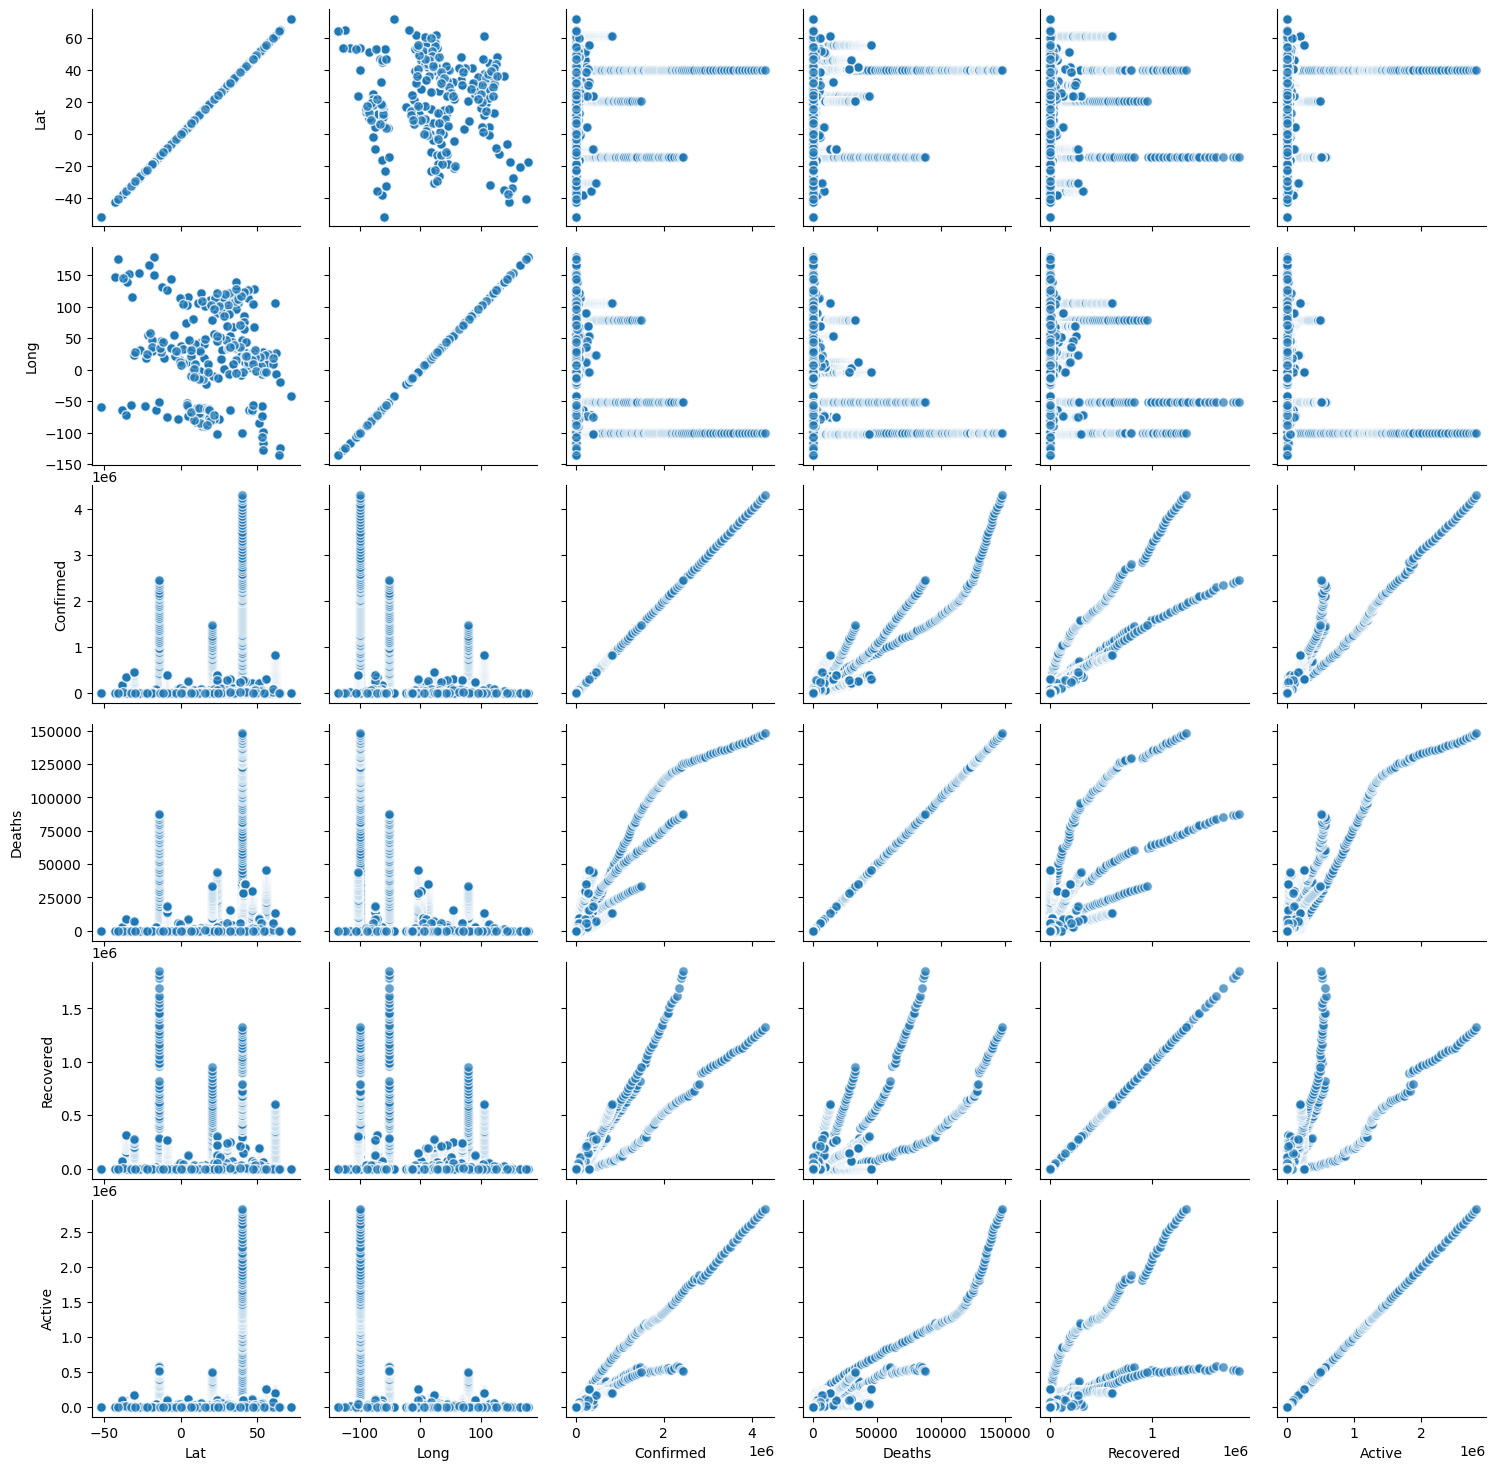

In [12]:
grid = sns.PairGrid(df) 
grid.map(func=plt.scatter, s=50, edgecolor='w', alpha=0.7)

In [13]:
CorrMatrix = df.drop(['Country/Region','WHO Region','Date'],axis = 1).corr()

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5]),
 [Text(0, 0.5, 'Lat'),
  Text(0, 1.5, 'Long'),
  Text(0, 2.5, 'Confirmed'),
  Text(0, 3.5, 'Deaths'),
  Text(0, 4.5, 'Recovered'),
  Text(0, 5.5, 'Active')])

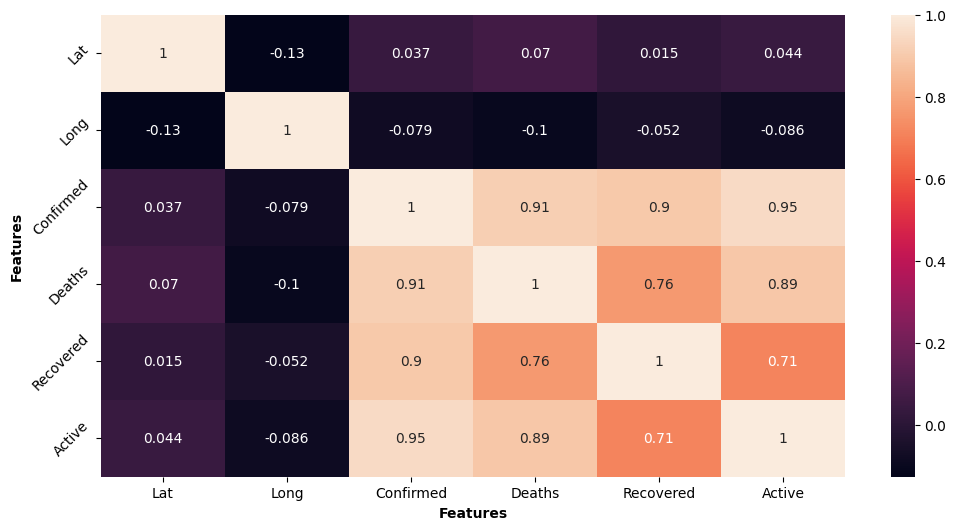

In [14]:
plt.figure(figsize = (12,6))
sns.heatmap(data = CorrMatrix,annot = True) 
plt.ylabel("Features", fontweight = 'bold')
plt.xlabel("Features", fontweight = 'bold')
plt.yticks(rotation = 45)

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5]),
 [Text(0, 0.5, 'Lat'),
  Text(0, 1.5, 'Long'),
  Text(0, 2.5, 'Confirmed'),
  Text(0, 3.5, 'Deaths'),
  Text(0, 4.5, 'Recovered'),
  Text(0, 5.5, 'Active')])

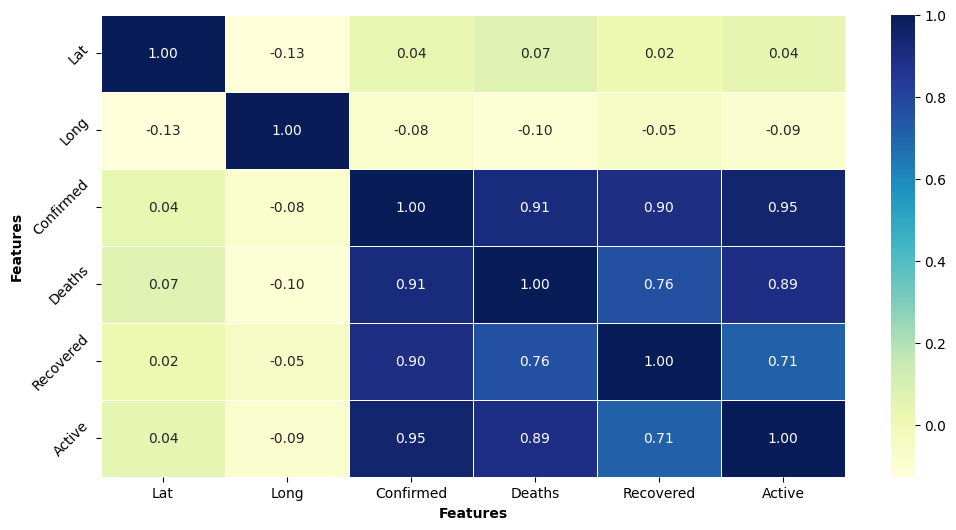

In [15]:
plt.figure(figsize=[12,6])
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5)
plt.ylabel("Features", fontweight = 'bold')
plt.xlabel("Features", fontweight = 'bold')
plt.yticks(rotation = 45)

In [16]:
df.groupby('Date')[['Deaths']].mean() 

,Deaths
Date,
2020-01-22,0.065134
2020-01-23,0.068966
2020-01-24,0.099617
2020-01-25,0.160920
2020-01-26,0.214559
...,...
2020-07-23,2427.226054
2020-07-24,2450.766284
2020-07-25,2469.413793


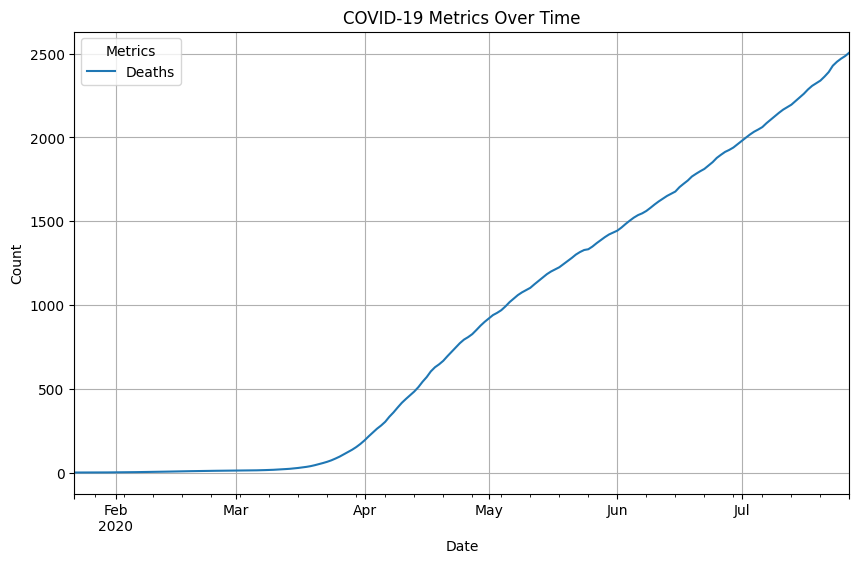

In [17]:
df_grouped = df.groupby('Date')[['Deaths']].mean() 
df_grouped.plot(figsize=(10,6)) 
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("COVID-19 Metrics Over Time")
plt.legend(title="Metrics")
plt.grid()
plt.show()

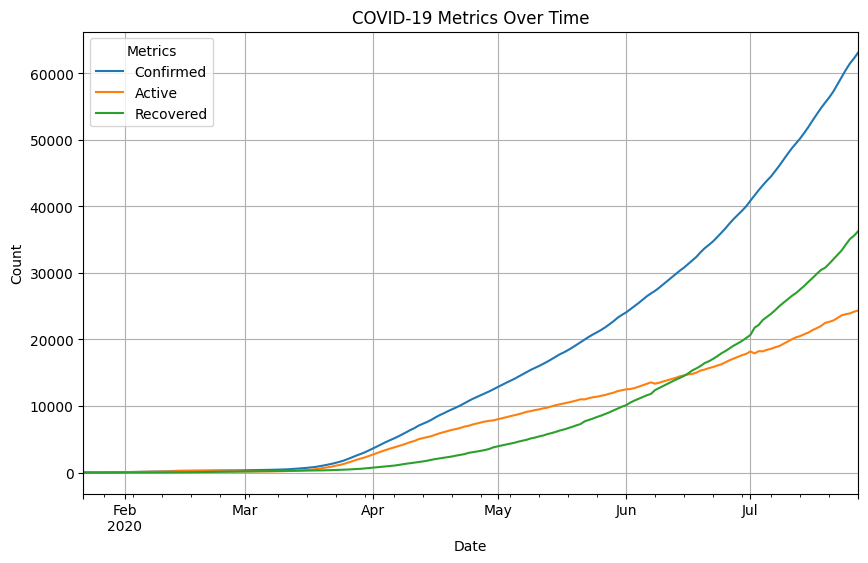

In [18]:
df_grouped = df.groupby('Date')[['Confirmed', 'Active', 'Recovered']].mean() 

df_grouped.plot(figsize=(10,6))
plt.xlabel("Date") 
plt.ylabel("Count") 
plt.title("COVID-19 Metrics Over Time") 
plt.legend(title="Metrics") 
plt.grid()
plt.show()

In [19]:
df['Year'] = df['Date'].dt.year 
df['Month'] = df['Date'].dt.month 
df['Day'] = df['Date'].dt.day 
df['DayOfWeek'] = df['Date'].dt.weekday 
df['WeekOfYear'] = df['Date'].dt.isocalendar().week 
df['DaysSinceStart'] = (df['Date'] - df['Date'].min()).dt.days 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country/Region  49068 non-null  object        
 1   Lat             49068 non-null  float64       
 2   Long            49068 non-null  float64       
 3   Date            49068 non-null  datetime64[ns]
 4   Confirmed       49068 non-null  int64         
 5   Deaths          49068 non-null  int64         
 6   Recovered       49068 non-null  int64         
 7   Active          49068 non-null  int64         
 8   WHO Region      49068 non-null  object        
 9   Year            49068 non-null  int32         
 10  Month           49068 non-null  int32         
 11  Day             49068 non-null  int32         
 12  DayOfWeek       49068 non-null  int32         
 13  WeekOfYear      49068 non-null  UInt32        
 14  DaysSinceStart  49068 non-null  int64         
dtypes:

Text(0.5, 1.0, 'The whole data including the country/region deaths each day')

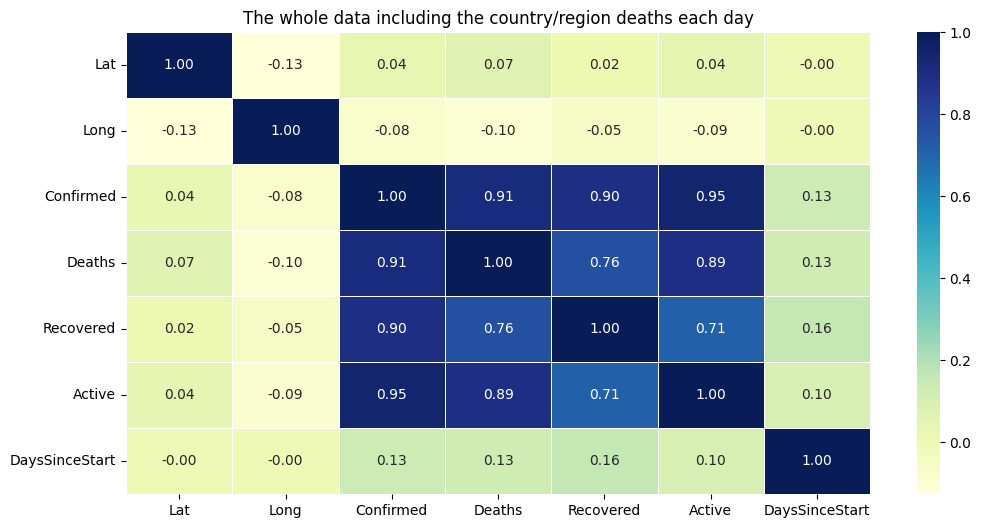

In [20]:
plt.figure(figsize=[12,6])
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(),
            annot=True,
            fmt=".2f", cmap="YlGnBu",
            linewidths=0.5)
plt.title("The whole data including the country/region deaths each day")

In [21]:
GROUPPED_DATA = df.groupby('Date')[['Deaths','Confirmed','DaysSinceStart','Active','Recovered']].mean().reset_index(drop=True)

Text(0.5, 1.0, 'While Groupped By')

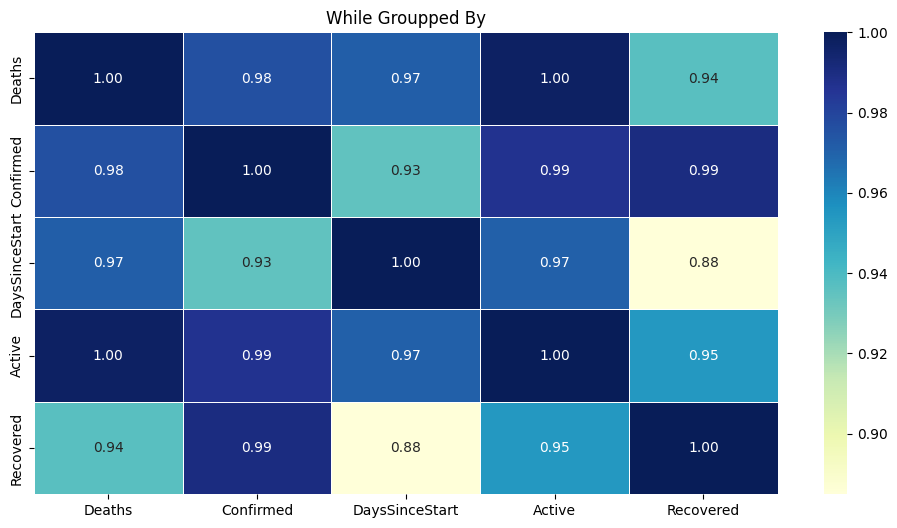

In [22]:
plt.figure(figsize=[12,6])
sns.heatmap(GROUPPED_DATA.corr(),
            annot=True,
            fmt=".2f", cmap="YlGnBu",
            linewidths=0.5)
plt.title("While Groupped By")

In [23]:
ML_data = df.groupby('Date')[['Confirmed', 'Active', 'Recovered','Deaths','DaysSinceStart']].mean()

In [24]:
ML_data

,Confirmed,Active,Recovered,Deaths,DaysSinceStart
Date,,,,,
2020-01-22,2.126437,1.954023,0.107280,0.065134,0.0
2020-01-23,2.505747,2.321839,0.114943,0.068966,1.0
2020-01-24,3.605364,3.367816,0.137931,0.099617,2.0
2020-01-25,5.494253,5.183908,0.149425,0.160920,3.0
2020-01-26,8.114943,7.701149,0.199234,0.214559,4.0
...,...,...,...,...,...
2020-07-23,59427.130268,23624.544061,33375.360153,2427.226054,183.0
2020-07-24,60504.386973,23801.877395,34251.743295,2450.766284,184.0
2020-07-25,61483.486590,23923.103448,35090.969349,2469.413793,185.0


In [25]:
ML_data.reset_index(drop=True,inplace=True)

In [26]:
ML_data.describe()

,Confirmed,Active,Recovered,Deaths,DaysSinceStart
count,188.000000,188.000000,188.000000,188.000000,188.000000
mean,16884.904255,8085.011617,7915.713479,884.179160,93.500000
std,18229.840316,7546.630075,10068.875077,834.977372,54.415071
min,2.126437,1.954023,0.107280,0.065134,0.000000
25%,429.850575,224.681034,231.575670,15.076628,46.750000
50%,10914.685824,7125.513410,3006.835249,782.337165,93.500000
75%,28436.955939,13743.353448,13089.638889,1603.963602,140.250000
max,63143.620690,24361.540230,36276.195402,2505.885057,187.000000


In [27]:
from sklearn.preprocessing import StandardScaler as SC 
from sklearn.model_selection import train_test_split as TTSPlit

In [28]:
X = ML_data[['Confirmed', 'Active', 'Recovered','DaysSinceStart']] 
y = ML_data['Deaths']

In [29]:
X.shape
X_train, X_test, y_train, y_test = TTSPlit(X, y, train_size = 0.8,shuffle=False)

In [30]:
scaler = SC() 
scaler.fit(X_train)

StandardScaler()

In [31]:
X_train_normalized = scaler.transform(X_train)
X_train_normalized.mean(), X_train_normalized.std()
X_test_nomralized = scaler.transform(X_test)
pd.DataFrame(X_train_normalized, columns = ['Confirmed', 'Active', 'Recovered','DaysSinceStart']).describe()

,Confirmed,Active,Recovered,DaysSinceStart
count,1.500000e+02,1.500000e+02,1.500000e+02,150.000000
mean,9.473903e-17,9.473903e-17,1.421085e-16,0.000000
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350
min,-9.098698e-01,-1.000856e+00,-7.747736e-01,-1.720542
25%,-8.782707e-01,-9.621865e-01,-7.440536e-01,-0.860271
50%,-4.168698e-01,-2.838818e-01,-5.508605e-01,0.000000
75%,7.309075e-01,8.908759e-01,4.983636e-01,0.860271
max,2.369211e+00,1.984460e+00,2.791984e+00,1.720542


In [32]:
from sklearn.linear_model import LinearRegression as LR
from sklearn.metrics import r2_score, mean_absolute_error

In [33]:
model = LR() 
model.fit(X_train_normalized, y_train)

LinearRegression()

In [34]:
y_pred = model.predict(X_test_nomralized)
MAE = mean_absolute_error(y_test, y_pred) 
R2 = r2_score(y_test, y_pred)
MAE,R2

(2.961841298536839e-12, 1.0)

In [35]:
df_eval = pd.DataFrame(data = y_test)
df_eval['Predicted'] = y_pred
df_eval

,Deaths,Predicted
150,1782.459770,1782.459770
151,1797.643678,1797.643678
152,1811.325670,1811.325670
153,1831.674330,1831.674330
154,1851.831418,1851.831418
155,1877.222222,1877.222222
156,1895.716475,1895.716475
157,1912.904215,1912.904215
158,1924.739464,1924.739464
159,1938.996169,1938.996169


In [36]:
ML_data

,Confirmed,Active,Recovered,Deaths,DaysSinceStart
0,2.126437,1.954023,0.107280,0.065134,0.0
1,2.505747,2.321839,0.114943,0.068966,1.0
2,3.605364,3.367816,0.137931,0.099617,2.0
3,5.494253,5.183908,0.149425,0.160920,3.0
4,8.114943,7.701149,0.199234,0.214559,4.0
...,...,...,...,...,...
183,59427.130268,23624.544061,33375.360153,2427.226054,183.0
184,60504.386973,23801.877395,34251.743295,2450.766284,184.0
185,61483.486590,23923.103448,35090.969349,2469.413793,185.0
186,62267.417625,24175.137931,35607.141762,2485.137931,186.0


In [37]:
ML_data.to_csv("ML_DATA_V1.csv",index = False) 
ML_data

,Confirmed,Active,Recovered,Deaths,DaysSinceStart
0,2.126437,1.954023,0.107280,0.065134,0.0
1,2.505747,2.321839,0.114943,0.068966,1.0
2,3.605364,3.367816,0.137931,0.099617,2.0
3,5.494253,5.183908,0.149425,0.160920,3.0
4,8.114943,7.701149,0.199234,0.214559,4.0
...,...,...,...,...,...
183,59427.130268,23624.544061,33375.360153,2427.226054,183.0
184,60504.386973,23801.877395,34251.743295,2450.766284,184.0
185,61483.486590,23923.103448,35090.969349,2469.413793,185.0
186,62267.417625,24175.137931,35607.141762,2485.137931,186.0


In [38]:
import warnings
warnings.filterwarnings('ignore')

In [39]:
ML_DATA = pd.read_csv("ML_DATA_V1.csv") 
X = ML_DATA[['Active','DaysSinceStart']]
y = ML_DATA['Deaths'] 

In [40]:
ML_DATA.columns

Index(['Confirmed', 'Active', 'Recovered', 'Deaths', 'DaysSinceStart'], dtype='object')

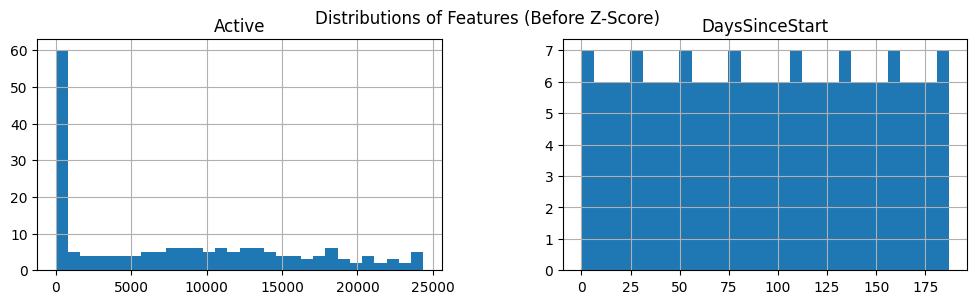

In [41]:
X.hist(bins=30, figsize=(12, 3))
plt.suptitle("Distributions of Features (Before Z-Score)")
plt.show()

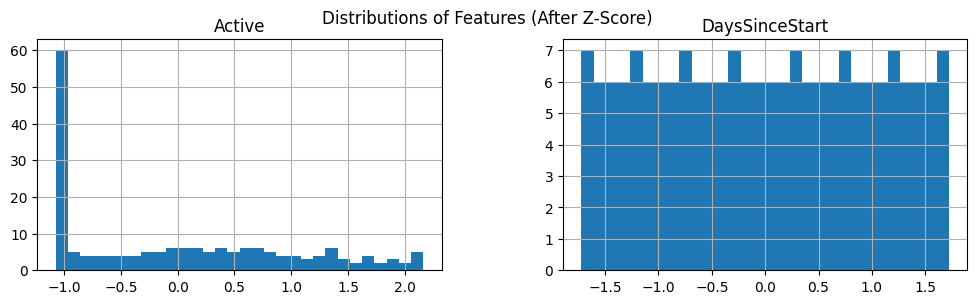

In [42]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler() 
X_norm = scaler.fit_transform(X)
X_norm = pd.DataFrame(X_norm, columns=X.columns) 

X_norm.hist(bins=30, figsize=(12, 3))
plt.suptitle("Distributions of Features (After Z-Score)")
plt.show()

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, LeaveOneOut, ShuffleSplit, cross_val_score


model = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

loo = LeaveOneOut() 

ss = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

kf_scores = cross_val_score(model, X_norm, y, cv=kf, scoring='r2')
print("KFold CV R2 Scores:", kf_scores)
print("KFold Mean R2: {:.3f} ± {:.3f}".format(kf_scores.mean(), kf_scores.std()))


loo_scores = cross_val_score(model, X_norm, y, cv=loo, scoring='neg_mean_squared_error')
print("Leave-One-Out CV Negative Mean Squared Error: {:.3f}".format(loo_scores.mean())) 
from numpy import sqrt

print("Leave-One-Out CV Root Mean Squared Error: {:.3f}".format(sqrt(-loo_scores.mean())))

ss_scores = cross_val_score(model, X_norm, y, cv=ss, scoring='r2')
print("ShuffleSplit CV R2 Scores:", ss_scores)
print("ShuffleSplit Mean R2: {:.3f} ± {:.3f}".format(ss_scores.mean(), ss_scores.std()))



KFold CV R2 Scores: [0.99465409 0.99323547 0.99195427 0.99507848 0.99299049]
KFold Mean R2: 0.994 ± 0.001
Leave-One-Out CV Negative Mean Squared Error: -4333.478
Leave-One-Out CV Root Mean Squared Error: 65.829
ShuffleSplit CV R2 Scores: [0.99465409 0.9931516  0.99661719 0.99262462 0.99243444]
ShuffleSplit Mean R2: 0.994 ± 0.002
